# 09 - Explainability (Cox HR + RSF SurvSHAP)

Hai lớp giải thích:

1. **Cox hazard ratio**: giải thích global, dễ trình bày.
2. **SurvSHAP(t)**: giải thích time-dependent cho RSF.

SHAP/SurvSHAP giải thích **đóng góp vào dự báo**, không chứng minh quan hệ nhân quả.

In [1]:
from pathlib import Path
import sys, yaml, pandas as pd, numpy as np

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))

with open(ROOT / "configs" / "experiment.yaml", "r", encoding="utf-8") as f:
    CFG = yaml.safe_load(f)

print("ROOT =", ROOT)
print("random_seed =", CFG["random_seed"])

ROOT = d:\VNUK\Eureka 2026\Eureka_2026
random_seed = 42


In [2]:
import matplotlib.pyplot as plt
from src.models import load_artifact, transform_X, make_y, predict_risk

MODE = "day0"
table_dir = ROOT / "results" / "tables"
fig_dir = ROOT / "results" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

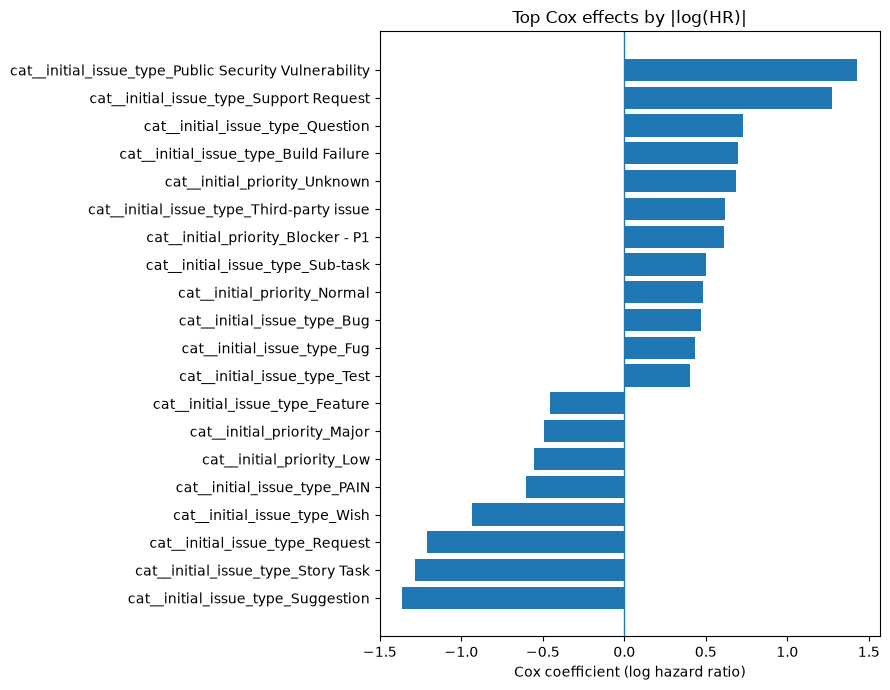

,feature,coef,hazard_ratio,abs_log_hr
0,cat__initial_issue_type_Public Security Vulner...,1.429042,4.174699,1.429042
1,cat__initial_issue_type_Suggestion,-1.361973,0.256155,1.361973
2,cat__initial_issue_type_Story Task,-1.285151,0.276609,1.285151
3,cat__initial_issue_type_Support Request,1.274288,3.576155,1.274288
4,cat__initial_issue_type_Request,-1.208462,0.298656,1.208462
5,cat__initial_issue_type_Wish,-0.932504,0.393567,0.932504
6,cat__initial_issue_type_Question,0.726877,2.068611,0.726877
7,cat__initial_issue_type_Build Failure,0.695400,2.004512,0.695400
8,cat__initial_priority_Unknown,0.684451,1.982683,0.684451
9,cat__initial_issue_type_Third-party issue,0.620568,1.859983,0.620568


In [3]:
# ---- Cox global explanation ----
hr_file = table_dir / f"cox_hazard_ratios_{MODE}.csv"
if not hr_file.exists():
    raise FileNotFoundError("Hãy chạy notebook 06 trước.")

hr = pd.read_csv(hr_file).sort_values("abs_log_hr", ascending=False)
top = hr.head(20).sort_values("coef")

plt.figure(figsize=(9, 7))
plt.barh(top["feature"], top["coef"])
plt.axvline(0, linewidth=1)
plt.xlabel("Cox coefficient (log hazard ratio)")
plt.title("Top Cox effects by |log(HR)|")
plt.tight_layout()
plt.savefig(fig_dir / f"cox_top_effects_{MODE}.png", dpi=200)
plt.show()

hr.head(30)

Nhớ hướng diễn giải:

- coefficient > 0 / HR > 1 → event **resolution** xảy ra nhanh hơn;
- coefficient < 0 / HR < 1 → resolution chậm hơn → issue có xu hướng tồn đọng lâu hơn.

In [4]:
# ---- Load RSF + reconstruct train/test from split file ----
rsf_file = ROOT / "results" / "models" / f"rsf_{MODE}.joblib"
split_file = table_dir / f"split_{MODE}.csv"
data_file = ROOT / "data" / "processed" / f"model_{MODE}.parquet"

if not rsf_file.exists():
    raise FileNotFoundError("Hãy chạy notebook 07 trước.")
if not split_file.exists():
    raise FileNotFoundError("Hãy chạy notebook 06 để tạo split file.")

artifact = load_artifact(rsf_file)
data = pd.read_parquet(data_file)
splits = pd.read_csv(split_file)

keys = ["repository", "project", "issue_key"]
merged = data.merge(splits, on=keys, how="left")

train = merged[merged["split"] == "train"].copy()
test = merged[merged["split"] == "test"].copy()

print("Train:", len(train), "Test:", len(test))

Train: 576268 Test: 172134


In [5]:
# ---- Robust global fallback: permutation importance trên RSF score ----
from sklearn.inspection import permutation_importance

sample = test.sample(n=min(2000, len(test)), random_state=CFG["random_seed"])
X_sample = transform_X(artifact, sample)
y_sample = make_y(sample)

perm = permutation_importance(
    artifact["model"],
    X_sample,
    y_sample,
    n_repeats=5,
    random_state=CFG["random_seed"],
    n_jobs=1,
)

perm_df = pd.DataFrame({
    "feature": artifact["feature_names"],
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

perm_df.to_csv(table_dir / f"rsf_permutation_importance_{MODE}.csv", index=False)
perm_df.head(25)

,feature,importance_mean,importance_std
36,cat__initial_issue_type_Suggestion,0.018124,0.002584
2,num__initial_assigned,0.007034,0.001297
0,num__created_weekday,0.002673,0.000931
4,cat__initial_priority_Blocker,0.000933,0.000340
39,cat__initial_issue_type_Technical task,0.000931,0.000282
38,cat__initial_issue_type_Task,0.000250,0.000652
6,cat__initial_priority_Critical,0.000143,0.000053
13,cat__initial_priority_Medium,0.000103,0.000210
17,cat__initial_priority_Trivial,0.000088,0.000202
3,cat__initial_priority_,0.000000,0.000000


In [6]:
# ---- SurvSHAP(t): local explanation cho 1 issue ----
# Cố tình dùng background nhỏ vì SurvSHAP có thể tốn RAM/thời gian.
try:
    from survshap import SurvivalModelExplainer, PredictSurvSHAP

    bg = train.sample(n=min(200, len(train)), random_state=CFG["random_seed"]).copy()
    candidate = test.sample(n=min(500, len(test)), random_state=CFG["random_seed"]).copy()

    # Chọn issue có RSF risk score cao trong sample test.
    candidate_risk = predict_risk(artifact, candidate)
    pos = int(np.argmax(candidate_risk))
    obs = candidate.iloc[[pos]].copy()

    X_bg_arr = transform_X(artifact, bg)
    X_obs_arr = transform_X(artifact, obs)

    X_bg = pd.DataFrame(X_bg_arr, columns=artifact["feature_names"])
    X_obs = pd.DataFrame(X_obs_arr, columns=artifact["feature_names"])
    y_bg = make_y(bg)

    explainer = SurvivalModelExplainer(
        model=artifact["model"],
        data=X_bg,
        y=y_bg,
    )

    local = PredictSurvSHAP()
    local.fit(
        explainer=explainer,
        new_observation=X_obs,
    )

    local.result.to_csv(
        table_dir / f"survshap_local_{MODE}.csv",
        index=False,
    )

    print("Explained issue:")
    print(obs[["repository", "project", "issue_key", "duration_days", "event"]])

    local.plot()
    plt.tight_layout()
    plt.savefig(fig_dir / f"survshap_local_{MODE}.png", dpi=200, bbox_inches="tight")
    plt.show()

except Exception as e:
    print("SurvSHAP chưa chạy được:", repr(e))
    print(
        "Permutation importance phía trên vẫn là XAI global hợp lệ. "
        "Nếu lỗi liên quan SHAP version, xem README đi kèm bundle."
    )

d:\VNUK\Eureka 2026\Eureka_2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\VNUK\Eureka 2026\Eureka_2026\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomSurvivalForest was fitted without feature names
  warnings.warn(
d:\VNUK\Eureka 2026\Eureka_2026\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomSurvivalForest was fitted without feature names
  warnings.warn(


SurvSHAP chưa chạy được: MemoryError()
Permutation importance phía trên vẫn là XAI global hợp lệ. Nếu lỗi liên quan SHAP version, xem README đi kèm bundle.
